**-------------------------------------------------------Week07-Task02-Book Recommender-----------------------------------------------------------**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1.Load the dataset using pd.read csv. What are the shapes of the dataset, and what are
the column names?**

In [ ]:
df = pd.read_csv('books.csv', on_bad_lines='skip')

In [ ]:
print("Number of Rows: ",df.shape[0])
print("Number of Columns: ",df.shape[1])

Number of Rows:  11123
Number of Columns:  12


In [ ]:
cols = [col for col in df.columns]

In [ ]:
cols

['bookID',
 'title',
 'authors',
 'average_rating',
 'isbn',
 'isbn13',
 'language_code',
 '  num_pages',
 'ratings_count',
 'text_reviews_count',
 'publication_date',
 'publisher']

– Load and explore the dataset using pandas (info(), describe(), head())

In [ ]:
df.head(5)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [ ]:
df.describe()

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11123.000000,11123.000000,1.112300e+04,11123.000000,1.112300e+04,11123.000000
mean,21310.856963,3.934075,9.759880e+12,336.405556,1.794285e+04,542.048099
std,13094.727252,0.350485,4.429758e+11,241.152626,1.124992e+05,2576.619589
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10277.500000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780582e+12,299.000000,7.450000e+02,47.000000
75%,32104.500000,4.140000,9.780872e+12,416.000000,5.000500e+03,238.000000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


**2.Confirm there are no missing values. Why is this critical for the recommendation system?**


In [ ]:
df.isnull().sum()

,0
bookID,0
title,0
authors,0
average_rating,0
isbn,0
isbn13,0
language_code,0
num_pages,0
ratings_count,0
text_reviews_count,0


**EDA using Visualization**

Bar plot of top 10 books with over 1M ratings, sorted by average rating

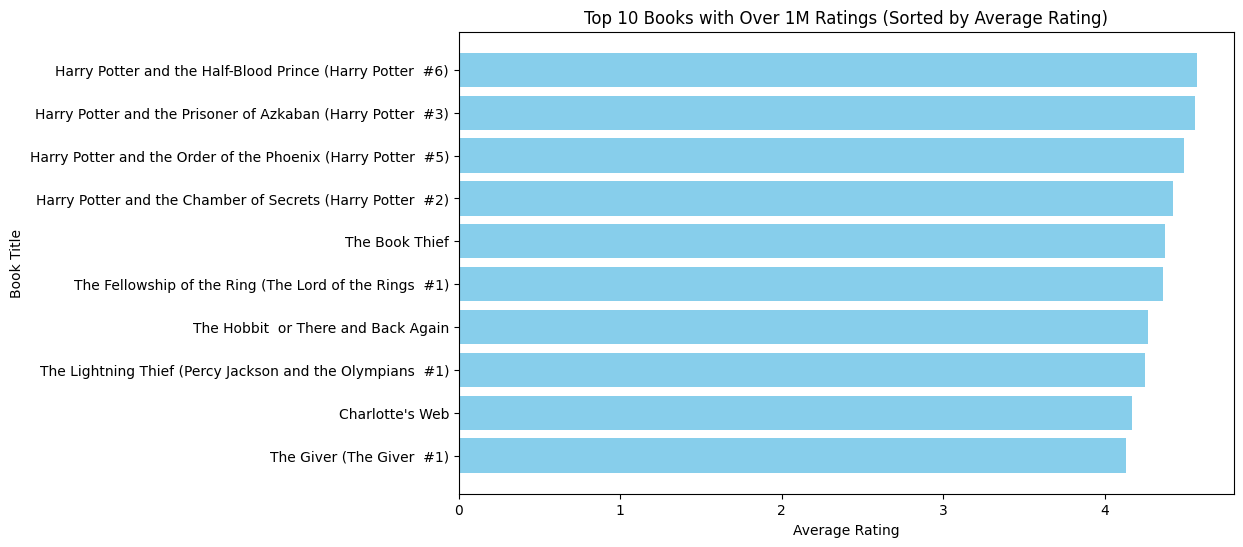

In [ ]:
df_filtered = df[df["ratings_count"] > 1_000_000]

# Sort by average rating (descending) and select top 10
top_books = df_filtered.sort_values("average_rating", ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top_books["title"], top_books["average_rating"], color="skyblue")
plt.xlabel("Average Rating")
plt.ylabel("Book Title")
plt.title("Top 10 Books with Over 1M Ratings (Sorted by Average Rating)")
plt.gca().invert_yaxis()  # so the best book is at the top
plt.show()

Bar plot of top 10 authors by number of books.

/tmp/ipython-input-4063920947.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_authors.values, y=top_authors.index, palette="viridis")


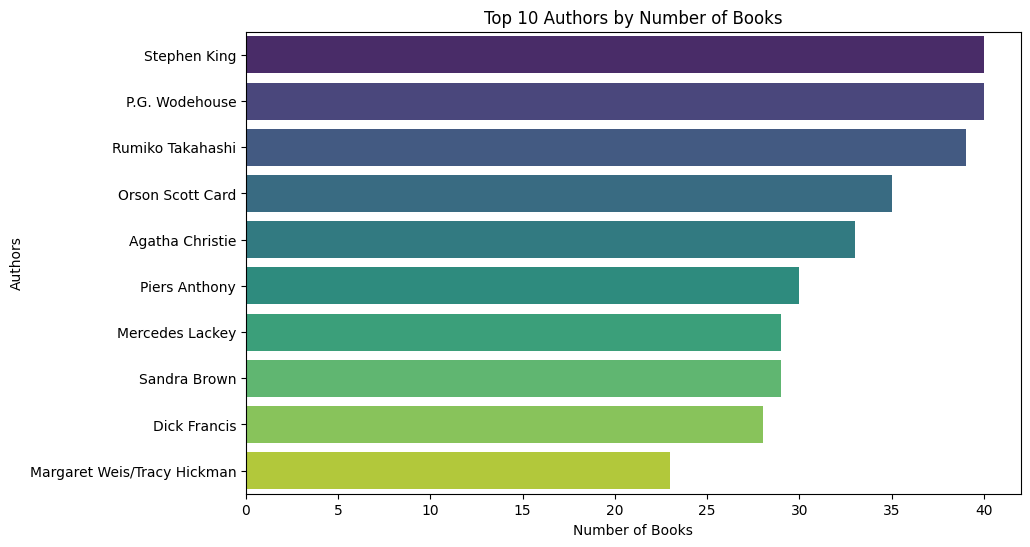

In [ ]:
top_authors = df['authors'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_authors.values, y=top_authors.index, palette="viridis")
plt.title("Top 10 Authors by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Authors")
plt.show()


Bar plot of top 10 most-rated books by ratings count.

/tmp/ipython-input-1106001812.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="ratings_count", y="title", data=top_books, palette="magma")


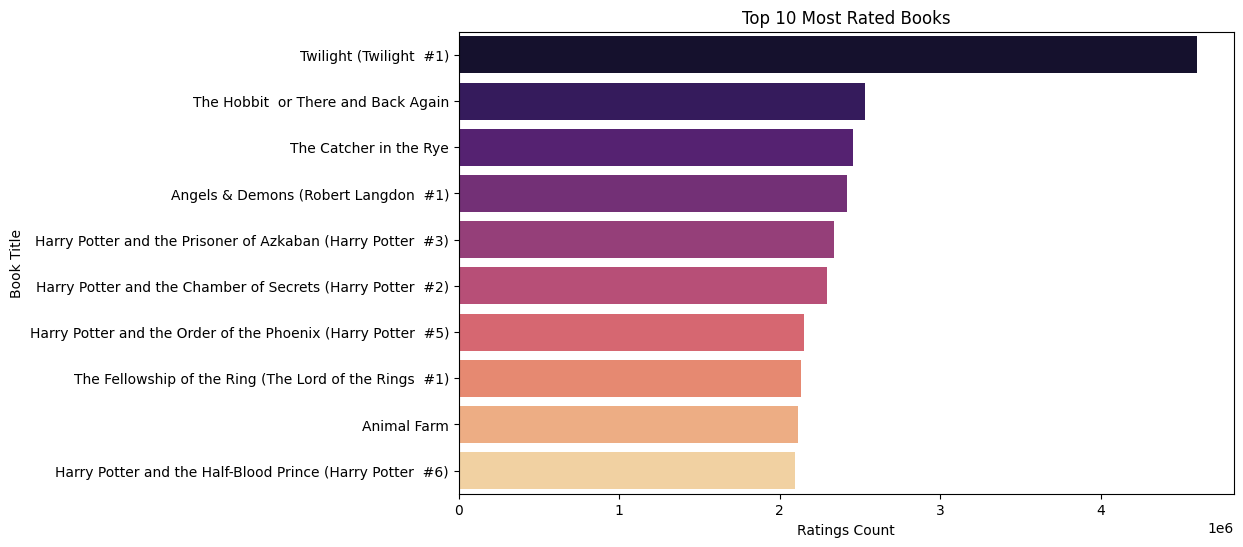

In [ ]:
top_books = df.nlargest(10, "ratings_count")

plt.figure(figsize=(10,6))
sns.barplot(x="ratings_count", y="title", data=top_books, palette="magma")
plt.title("Top 10 Most Rated Books")
plt.xlabel("Ratings Count")
plt.ylabel("Book Title")
plt.show()


Countplot of books by language code (top 10 languages)

/tmp/ipython-input-3297274649.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_langs.index, y=top_langs.values, palette="cubehelix")


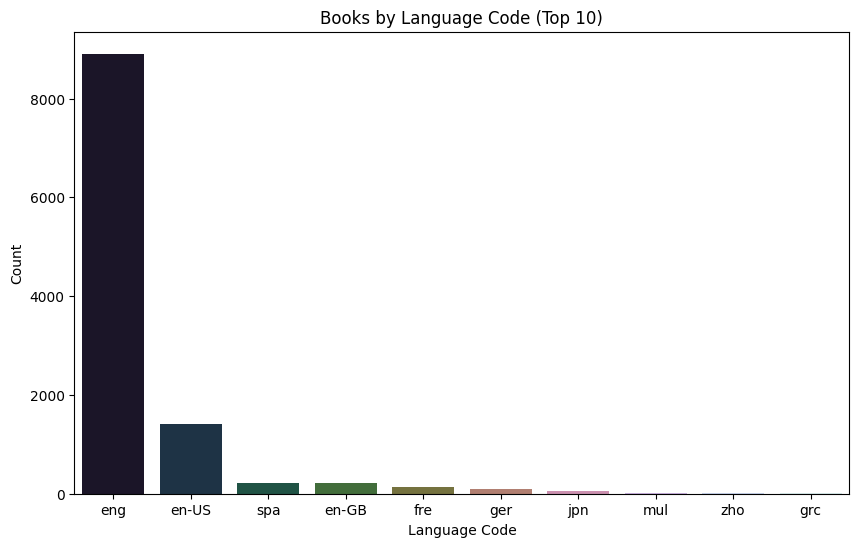

In [ ]:
top_langs = df['language_code'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_langs.index, y=top_langs.values, palette="cubehelix")
plt.title("Books by Language Code (Top 10)")
plt.xlabel("Language Code")
plt.ylabel("Count")
plt.show()


Bar plot of top 10 highly rated authors (books with average rating ¿ 4.4).

/tmp/ipython-input-1498754334.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=highly_rated_authors.values, y=highly_rated_authors.index, palette="coolwarm")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33618 (\N{CJK UNIFIED IDEOGRAPH-8352}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24029 (\N{CJK UNIFIED IDEOGRAPH-5DDD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24344 (\N{CJK UNIFIED IDEOGRAPH-5F18}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:

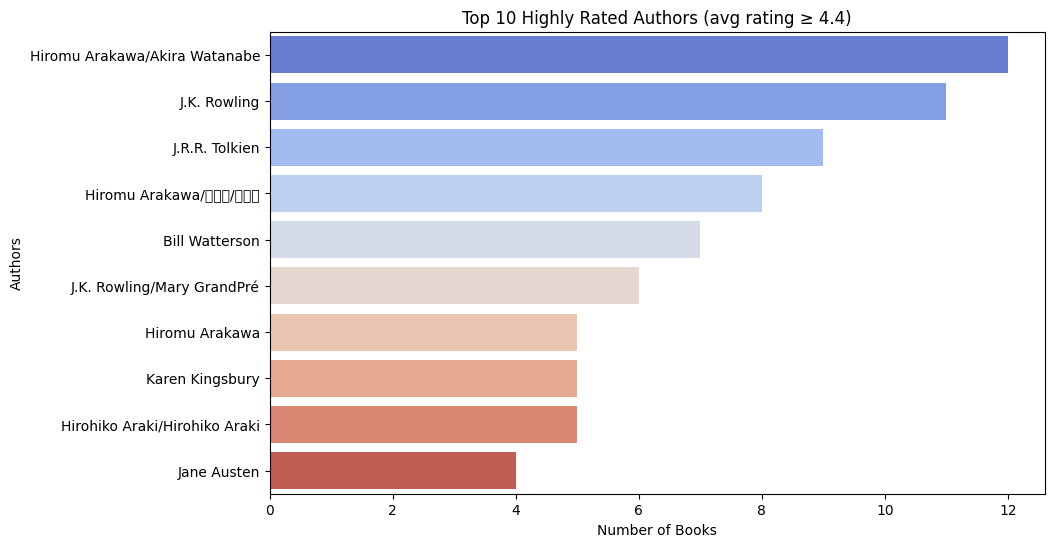

In [ ]:
highly_rated_authors = (
    df[df["average_rating"] >= 4.4]
    .groupby("authors")["average_rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=highly_rated_authors.values, y=highly_rated_authors.index, palette="coolwarm")
plt.title("Top 10 Highly Rated Authors (avg rating ≥ 4.4)")
plt.xlabel("Number of Books")
plt.ylabel("Authors")
plt.show()


Bar plot of top 10 publishers by number of books.


/tmp/ipython-input-1032213096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="plasma")


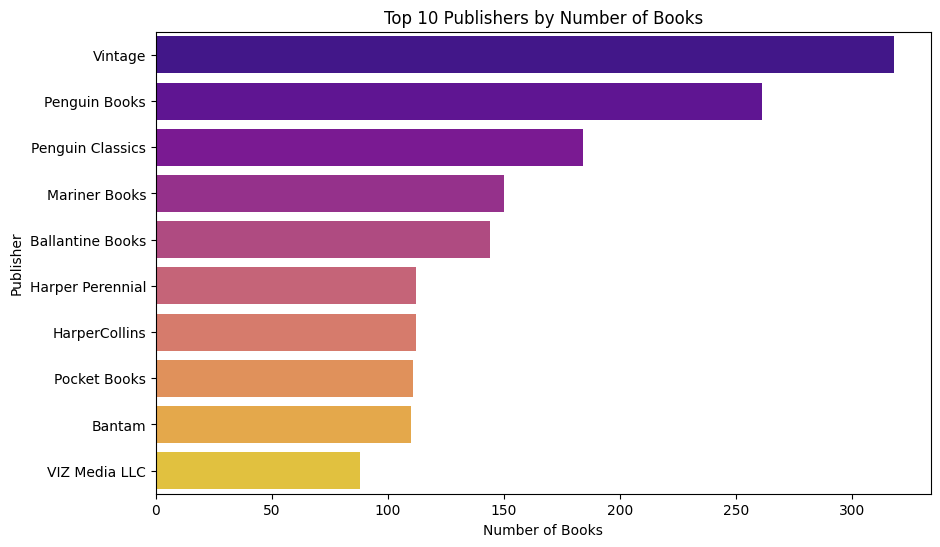

In [ ]:
top_publishers = df['publisher'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="plasma")
plt.title("Top 10 Publishers by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Publisher")
plt.show()


Distribution plot of average rating.

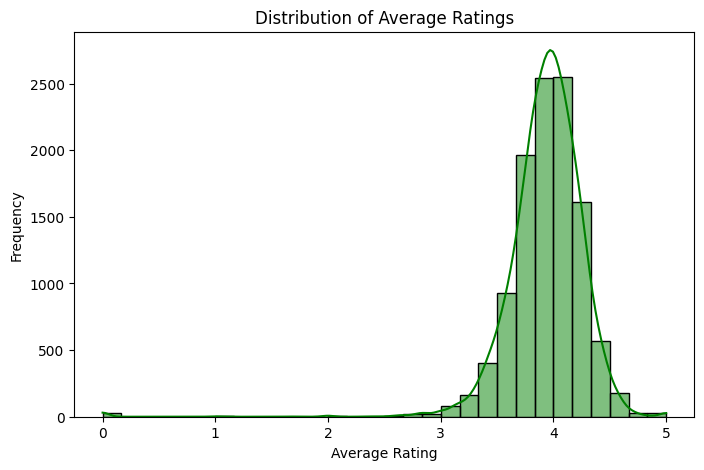

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["average_rating"], bins=30, kde=True, color="green")
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()


Relationship plots (relplot) of average rating vs. ratings count, num pages,
language code, and text reviews count

In [ ]:
# sns.relplot(x="ratings_count", y="average_rating", data=df, height=5, aspect=1.5)
# sns.relplot(x="num_pages", y="average_rating", data=df, height=5, aspect=1.5)
# sns.relplot(x="text_reviews_count", y="average_rating", data=df, height=5, aspect=1.5)


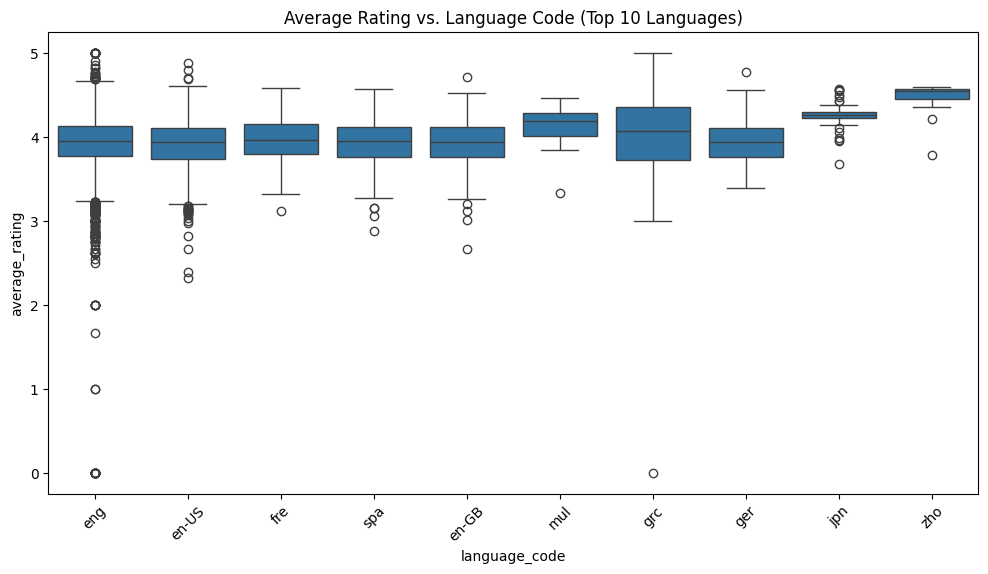

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x="language_code", y="average_rating", data=df[df['language_code'].isin(df['language_code'].value_counts().head(10).index)])
plt.xticks(rotation=45)
plt.title("Average Rating vs. Language Code (Top 10 Languages)")
plt.show()


**3.Convert rating between and language code to dummy variables. How many
new columns were added?**


In [ ]:
df["rating_between"] = pd.cut(df["average_rating"],
                              bins=[0,1,2,3,4,5],
                              labels=["0-1","1-2","2-3","3-4","4-5"])

In [ ]:
print(df["rating_between"].value_counts())

rating_between
3-4    6285
4-5    4735
2-3      69
1-2       7
0-1       2
Name: count, dtype: int64


**4.Convert rating between and language code to dummy variables. How many
new columns were added?**

In [ ]:
lang_dummies = pd.get_dummies(df["language_code"], prefix="lang", drop_first=True)
rating_dummies = pd.get_dummies(df["rating_between"], prefix="rating", drop_first=True)

print("Language dummies:", lang_dummies.shape[1])
print("Rating dummies:", rating_dummies.shape[1])


Language dummies: 26
Rating dummies: 4


Scaling is critical for k-NN because it uses distance metrics (Euclidean, BallTree).

Without scaling, features like ratings_count (can be in millions) would dominate over average_rating (only 0–5).

**5.Apply MinMaxScaler to the feature matrix. Why is scaling important for k-NN?**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = pd.concat([lang_dummies, rating_dummies, df[["average_rating","ratings_count"]]], axis=1)

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)


**6.Build and fit the k-NN model. Why was algorithm=’ball tree’ chosen?**


In [ ]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=6, algorithm="ball_tree")
knn.fit(features_scaled)


NearestNeighbors(algorithm='ball_tree', n_neighbors=6)

**7.Test the BookRecommender function with two book titles. Are the recommendations
reasonable? Explain.**

Yes the recommendations were reasonable



In [ ]:
# def BookRecommender(book_title, df=df, knn=knn, features_scaled=features_scaled):
#     if book_title not in df["title"].values:
#         return f"'{book_title}' not found in dataset."
#     idx = df[df["title"] == book_title].index[0]
#     distances, indices = knn.kneighbors([features_scaled[idx]])
#     recommended = df.iloc[indices[0]][["title", "authors", "average_rating", "ratings_count"]]
#     return recommended


from tabulate import tabulate

def BookRecommender(book_title, df=df, knn=knn, features_scaled=features_scaled):
    if book_title not in df["title"].values:
        return f"'{book_title}' not found in dataset."

    idx = df[df["title"] == book_title].index[0]
    distances, indices = knn.kneighbors([features_scaled[idx]])

    recommended = df.iloc[indices[0]][["title", "authors", "average_rating", "ratings_count"]]

    return tabulate(recommended, headers="keys", tablefmt="pretty", showindex=False)


In [ ]:

print(BookRecommender("The Hobbit"))
# print(BookRecommender("Pride and Prejudice"))


+-------------------------------------------------------------------------------+----------------------------+----------------+---------------+
|                                     title                                     |          authors           | average_rating | ratings_count |
+-------------------------------------------------------------------------------+----------------------------+----------------+---------------+
|                                  The Hobbit                                   |       J.R.R. Tolkien       |      4.27      |     3213      |
| The Voyage of the Jerle Shannara Trilogy (Voyage of the Jerle Shannara  #1-3) |        Terry Brooks        |      4.27      |     3088      |
|                     Tsubasa: RESERVoir CHRoNiCLE  Vol. 8                      |   CLAMP/William Flanagan   |      4.27      |     2993      |
|                              The Complete Plays                               |    Sophocles/Paul Roche    |      4.27      |     2883

**8.Visualize the distribution of distances returned by model.kneighbors for one book.
What does this indicate about the recommendation quality?**


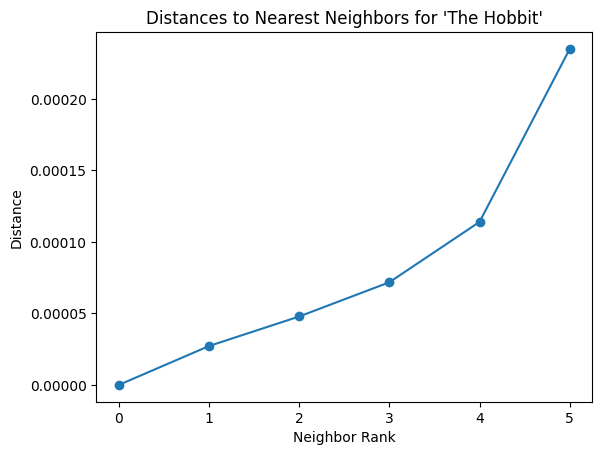

In [ ]:
import matplotlib.pyplot as plt

idx = df[df["title"]=="The Hobbit"].index[0]
distances, indices = knn.kneighbors([features_scaled[idx]])

plt.plot(distances[0], marker="o")
plt.title("Distances to Nearest Neighbors for 'The Hobbit'")
plt.xlabel("Neighbor Rank")
plt.ylabel("Distance")
plt.show()


In [ ]:
for n in [3, 10]:
    knn_test = NearestNeighbors(n_neighbors=n, algorithm="ball_tree")
    knn_test.fit(features_scaled)
    idx = df[df["title"]=="The Hobbit"].index[0]
    distances, indices = knn_test.kneighbors([features_scaled[idx]])
    print(f"\nTop {n} recommendations for 'The Hobbit':")
    print(df.iloc[indices[0]][["title", "authors"]])



Top 3 recommendations for 'The Hobbit':
                                                  title  \
1701                                         The Hobbit   
4321  The Voyage of the Jerle Shannara Trilogy (Voya...   
3760               Tsubasa: RESERVoir CHRoNiCLE  Vol. 8   

                     authors  
1701          J.R.R. Tolkien  
4321            Terry Brooks  
3760  CLAMP/William Flanagan  

Top 10 recommendations for 'The Hobbit':
                                                   title  \
1701                                          The Hobbit   
4321   The Voyage of the Jerle Shannara Trilogy (Voya...   
3760                Tsubasa: RESERVoir CHRoNiCLE  Vol. 8   
484                                   The Complete Plays   
3171                         Ariel: The Restored Edition   
9796                The Forbidden (Vampire Huntress  #5)   
4520                   Agatha Christie: An Autobiography   
7753                                        What Work Is   
10081           

**9.Save the k-NN model using pickle. Why is this step important for reproducibility?**


In [ ]:
import pickle

# Bundle everything in a dict
artifacts = {
    "book_recommender_knn_model": knn,
    "scaler": scaler,
    "features": features_scaled,
    "data": df  # keep reference to the dataset (titles, authors, etc.)
}

# Save to pickle
with open("book_recommender.pkl", "wb") as f:
    pickle.dump(artifacts, f)


In [ ]:
# Load pickle
with open("book_recommender.pkl", "rb") as f:
    artifacts = pickle.load(f)

# Extract
knn_loaded = artifacts["book_recommender_knn_model"]
scaler_loaded = artifacts["scaler"]
features_loaded = artifacts["features"]
df_loaded = artifacts["data"]

# Use the recommender
print(BookRecommender("Pride and Prejudice", df=df_loaded, knn=knn_loaded, features_scaled=features_loaded))


+-------------------------------------------------------+-------------------------------------+----------------+---------------+
|                         title                         |               authors               | average_rating | ratings_count |
+-------------------------------------------------------+-------------------------------------+----------------+---------------+
|                  Pride and Prejudice                  |             Jane Austen             |      4.26      |     2399      |
|  The Little Red Lighthouse and the Great Gray Bridge  |   Hildegarde Hoyt Swift/Lynd Ward   |      4.26      |     2276      |
|        Tell Me How Long the Train's Been Gone         |            James Baldwin            |      4.26      |     2162      |
|     His Dark Materials (His Dark Materials  #1-3)     |           Philip Pullman            |      4.26      |     2656      |
|                The Best Short Stories                 | Fyodor Dostoyevsky/David Magarshack |  

In [ ]:
print(BookRecommender("The Hobbit", df=df_loaded, knn=knn_loaded, features_scaled=features_loaded))

+-------------------------------------------------------------------------------+----------------------------+----------------+---------------+
|                                     title                                     |          authors           | average_rating | ratings_count |
+-------------------------------------------------------------------------------+----------------------------+----------------+---------------+
|                                  The Hobbit                                   |       J.R.R. Tolkien       |      4.27      |     3213      |
| The Voyage of the Jerle Shannara Trilogy (Voyage of the Jerle Shannara  #1-3) |        Terry Brooks        |      4.27      |     3088      |
|                     Tsubasa: RESERVoir CHRoNiCLE  Vol. 8                      |   CLAMP/William Flanagan   |      4.27      |     2993      |
|                              The Complete Plays                               |    Sophocles/Paul Roche    |      4.27      |     2883